In [1]:
# Work with numeric arrays and cell masks.
import numpy as np
# Summarize cells and results in tables.
import pandas as pd

# Open count stores and run Scarf analyses.
import scarf

# Keep routine logs and progress bars out of the results.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
# Open the count store for this analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Open the saved pancreas analysis.
analysis_run = ds.pipeline.open(label="docs_default")
# Keep the graph from the saved analysis.
graph = analysis_run["connectivity_map"]
# Keep the full feature selection for marker testing.
all_features = analysis_run["feature_universe"]
# Inspect the opened store's cells and features.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

In [2]:
# Read the published cell types for the selected cells.
labels = ds.cells.fetch("clusters", key="I")
# Choose Ductal cells as the starting population.
source = labels == "Ductal"
# Choose the pooled endocrine endpoints.
sink = np.isin(labels, ["Alpha", "Beta", "Delta"])
# Stop if either chosen endpoint population is absent.
if not source.any() or not sink.any():
    raise ValueError("Source and sink labels must both be present")
# Start with zero weight for cells outside the endpoints.
source_sink_vector = np.zeros(len(labels), dtype=float)
# Share a total weight of minus one across the source cells.
source_sink_vector[source] = -1.0 / source.sum()
# Share a total weight of plus one across the sink cells.
source_sink_vector[sink] = 1.0 / sink.sum()
# Check the endpoint sizes and balanced total weights.
{
    "source cells": int(source.sum()),
    "sink cells": int(sink.sum()),
    "source weight": round(float(source_sink_vector[source].sum()), 6),
    "sink weight": round(float(source_sink_vector[sink].sum()), 6),
}

{'source cells': 916,
 'sink cells': 1142,
 'source weight': -1.0,
 'sink weight': 1.0}

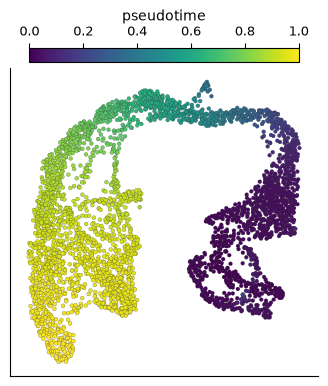

In [3]:
# Score pseudotime using the chosen source and sink weights.
pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)
# Load pseudotime scores and their validity mask.
pseudotime = ds.load_pseudotime_scoring(pseudotime_ref)
# Save the calculated values in the cell table.
ds.cells.insert("pseudotime", pseudotime.values, key="I", overwrite=True)
# Show how pseudotime changes across the pancreas UMAP.
ds.plots.embedding(layout=analysis_run['umap'], color_by='pseudotime', sort_values=True)

In [4]:
# Summarize the selected values and their spread.
pd.DataFrame(
    {
        "cell type": labels[pseudotime.valid],
        "pseudotime": pseudotime.values[pseudotime.valid],
    }
).groupby("cell type")["pseudotime"].describe()

,count,mean,std,min,25%,50%,75%,max
cell type,,,,,,,,
Alpha,481.0,0.958600,0.011519,0.854478,0.954543,0.961917,0.966559,0.975109
Beta,591.0,0.969641,0.020167,0.910871,0.955089,0.969660,0.986822,1.000000
Delta,70.0,0.920603,0.006220,0.903510,0.917825,0.921493,0.922952,0.943655
Ductal,916.0,0.022825,0.015730,0.000000,0.010842,0.023882,0.030093,0.120071
Epsilon,142.0,0.922423,0.029085,0.834411,0.908502,0.928372,0.946040,0.960314
Ngn3 high EP,642.0,0.499842,0.176005,0.086534,0.379658,0.548114,0.624802,0.769385
Ngn3 low EP,262.0,0.053563,0.037662,0.000263,0.029102,0.039294,0.077263,0.297250
Pre-endocrine,592.0,0.862448,0.061309,0.424159,0.814672,0.875902,0.916073,0.952458


In [5]:
# Test the selected genes for association with pseudotime.
marker_ref = ds.run_pseudotime_marker_search(pseudotime_ref, features=all_features)
# Load the marker table and adjusted p-values.
markers = ds.load_pseudotime_markers(marker_ref)
# Inspect the first few rows of the result.
markers.table.head()

,feature_index,feature_name,feature_id,r_value,p_value,p_value_adjusted
0,0,Xkr4,Xkr4,0.0,NaN,NaN
1,1,Gm37381,Gm37381,0.0,NaN,NaN
2,2,Rp1,Rp1,0.0,NaN,NaN
3,3,Rp1-1,Rp1-1,0.0,NaN,NaN
4,4,Sox17,Sox17,0.0,NaN,NaN


In [6]:
# Keep genes with an adjusted p-value.
tested = markers.table.loc[
    markers.table["p_value_adjusted"].notna(),
    ["feature_name", "r_value", "p_value_adjusted"],
]
# Select the ten strongest positive correlations.
increasing = tested.loc[tested["r_value"] > 0].nlargest(10, "r_value")
# Select the ten strongest negative correlations.
decreasing = tested.loc[tested["r_value"] < 0].nsmallest(10, "r_value")
# Display increasing and decreasing genes together.
pd.concat({"increasing": increasing, "decreasing": decreasing})

feature_name   r_value  p_value_adjusted
increasing 14296         Gnas  0.733567               0.0
           23549          Cpe  0.727497               0.0
           21244        Aplp1  0.724603               0.0
           3186       Fam183b  0.667334               0.0
           25060        Hmgn3  0.634924               0.0
           26573         Bex2  0.622213               0.0
           26730       Pcsk1n  0.619926               0.0
           2189         Rap1b  0.598697               0.0
           4284           Ubb  0.596692               0.0
           5837          Scgn  0.593868               0.0
decreasing 18864         Spp1 -0.828276               0.0
           24581        Rpl13 -0.822456               0.0
           22385        Rps19 -0.813066               0.0
           16254         Rps8 -0.809460               0.0
           431            Dbi -0.798188               0.0
           19815        Rpl32 -0.783291               0.0
           26498        Rps4x -0.782105               0.0
           13425        Rpl12 -0.768214               0.0
           10164         Rps2 -0.754602               0.0
           20787        Mgst1 -0.745689               0.0